Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Starting training for 50000 steps...
Logging to ./logs/ppo_trading_tensorboard/PPO_8


/Users/qwer/files/developer/stock_proj/.venv/lib/python3.12/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 2.04e+03 |
|    ep_rew_mean     | -83.7    |
| time/              |          |
|    fps             | 1823     |
|    iterations      | 1        |
|    time_elapsed    | 1        |
|    total_timesteps | 2048     |
---------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 2.04e+03     |
|    ep_rew_mean          | -76.8        |
| time/                   |              |
|    fps                  | 1516         |
|    iterations           | 2            |
|    time_elapsed         | 2            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0075993454 |
|    clip_fraction        | 0.0481       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.09        |
|    explained_variance   | -0.169       |
|    learning_r

Training complete. Model saved.


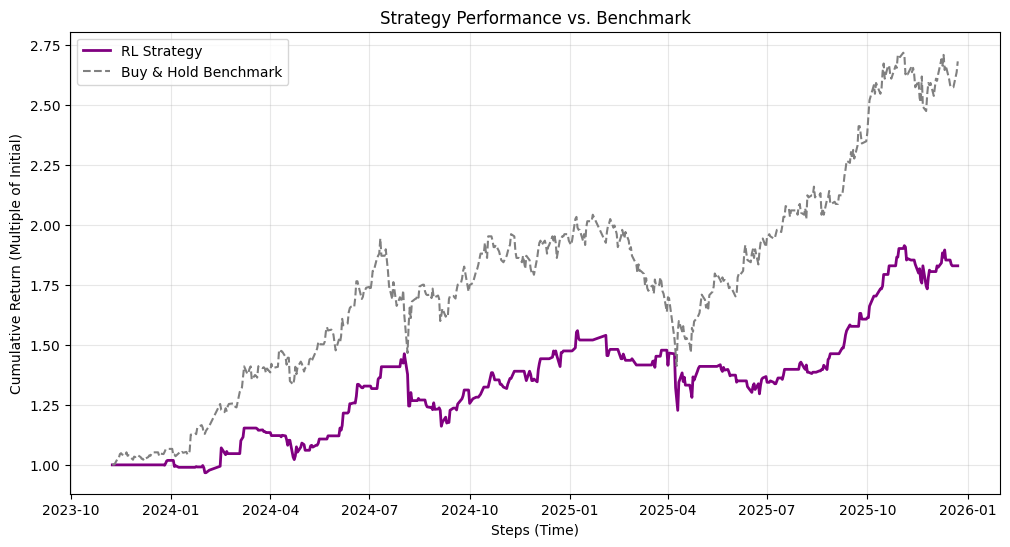

--- Performance Report ---
Total_Return: 0.8287
Sharpe_Ratio: 1.2829
Max_Drawdown: -0.2129


In [2]:
# Cell 1: Import modules and load/process data
import pandas as pd
import sys
import os

# Get the absolute path to the directory containing the current notebook
# and then move up one level to the project root
module_path = os.path.abspath(os.path.join('..'))

if module_path not in sys.path:
       sys.path.append(module_path)

# Now you can import from the modules folder
from modules.data_processor import FeatureFactory
from modules.environment import StockTradingEnv
from modules.model_agent import TradingAgent
from modules.rewards import RewardFunction
# Assuming evaluator.py exists for Module E
from modules.evaluator import Evaluator  # If not present, skip evaluation

# Load raw data
raw_df = pd.read_csv('../data/2330_2015-2025.csv')

# Process data with Module A
factory = FeatureFactory()
train_df, test_df = factory.process_and_split(raw_df)

# Create environment with Module B for training
train_env = StockTradingEnv(df=train_df, initial_balance=10000.0, window_size=30)
# Create a separate environment for testing
test_env = StockTradingEnv(df=test_df, initial_balance=10000.0, window_size=30)


# Initialize agent with Module D
agent = TradingAgent(env=train_env, model_path="../models/")

# Train the agent (adjust timesteps as needed)
agent.train(total_timesteps=50000)

# Basic evaluation: Run a test episode and log results
obs, _ = test_env.reset()
done = False
trade_log = []
while not done:
       action = agent.predict_action(obs)
       obs, reward, done, truncated, info = test_env.step(action)
       trade_log.append(info)
# Mock data for demonstration if you haven't run the model yet:
# trade_log = [{'step': 0, 'balance': 10000}, {'step': 50, 'balance': 11500}]
# price_history = processed_df['Close'].iloc[test_indices]
# # Initialize and Run Evaluation
evaluator = Evaluator(initial_balance=10000)
report = evaluator.evaluate(trade_log, test_df['raw_close'])

print("--- Performance Report ---")
for key, value in report.items():
       print(f"{key}: {value}")